<a href="https://colab.research.google.com/github/ka-means/adaptive-autonomy-lab/blob/main/02_reconstructing_multi_source_failure_modes_git_ready.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02 — Reconstructing failure modes in multi-source autonomous decision-making

## Research problem

Consider a team of autonomous agents that must act on a shared mission while each agent holds only a local estimate of the world.

The agents may differ in:

- information freshness,
- observation quality,
- confidence calibration,
- dependence on common information sources.

The central question is:

> **When does agreement between autonomous agents cease to be evidence of correctness?**

This notebook reconstructs several established failure mechanisms from different research traditions in a common minimal environment.

## Evidence labels

- **REPRODUCTION** — a known phenomenon or experimental logic reconstructed from prior literature.
- **ADAPTATION** — a known phenomenon translated into the autonomous-team setting used here.
- **SYNTHESIS** — interaction of mechanisms usually studied in separate literatures.
- **HYPOTHESIS** — a proposed explanation or extension requiring independent validation.
- **EXPLORATORY RESULT** — an observed pattern that should not be interpreted as a general result.


## 1. Literature provenance

The experiments in this notebook are intentionally traceable to prior work.

| Mechanism used here | Literature lineage | What the literature establishes | What this notebook does |
|---|---|---|---|
| Local histories / partial information | Oliehoek & Amato (2016), *A Concise Introduction to Decentralized POMDPs* | Decentralized agents make sequential decisions from different local information histories | Uses a much simpler continuous-state setting to isolate information disagreement |
| Agreement / distributed fusion | Olfati-Saber & Shamma (2005), *Consensus Filters for Sensor Networks and Distributed Sensor Fusion* | Consensus can support distributed tracking and sensor fusion | Uses simple fusion baselines rather than implementing a full consensus filter |
| Unknown dependence between estimates | Julier & Uhlmann, Covariance Intersection literature | Treating correlated estimates as independent can produce overconfident fusion; CI addresses unknown cross-correlation | Explicitly injects common-mode errors to study dependence |
| Information freshness | Yates & Kaul (2019); Yates et al. (2021), Age of Information | Timeliness is a system variable distinct from throughput and conventional latency metrics | Gives agents observations of different ages and measures downstream decision quality |
| Confidence calibration | Guo et al. (2017), *On Calibration of Modern Neural Networks* | Model confidence need not match empirical correctness | Separates actual observation error from reported uncertainty |
| Low disagreement under changing conditions | Mesto & Cruz (2026), *The Consensus Paradox* | In multi-teacher RL, high agreement can coexist with severe failure when outdated expertise is amplified | Adapts the causal pattern from teachers/advice to autonomous agents sharing state information |
| Imperfect heterogeneous sources | A2R2, *Adaptive Multi-Source Fusion for Interactive Reinforcement Learning* | Current work studies error structure and adaptive use of imperfect advice sources | Motivates the later transition from static fusion to context-dependent trust |

### Key references

1. Oliehoek, F. A., & Amato, C. (2016). *A Concise Introduction to Decentralized POMDPs*. Springer. DOI: `10.1007/978-3-319-28929-8`.
2. Olfati-Saber, R., & Shamma, J. S. (2005). *Consensus Filters for Sensor Networks and Distributed Sensor Fusion*. IEEE CDC/ECC. DOI: `10.1109/CDC.2005.1583238`.
3. Julier, S. J., & Uhlmann, J. K. Covariance Intersection literature; see their tutorial application to SLAM, *Robotics and Autonomous Systems* 55(1), 2007. DOI: `10.1016/j.robot.2006.06.011`.
4. Yates, R. D., & Kaul, S. K. (2019). *The Age of Information: Real-Time Status Updating by Multiple Sources*. IEEE Transactions on Information Theory, 65(3), 1807–1827. DOI: `10.1109/TIT.2018.2871079`.
5. Yates, R. D., Sun, Y., Brown, D. R., Kaul, S. K., Modiano, E., & Ulukus, S. (2021). *Age of Information: An Introduction and Survey*. IEEE JSAC, 39(5), 1183–1210. DOI: `10.1109/JSAC.2021.3065072`.
6. Guo, C., Pleiss, G., Sun, Y., & Weinberger, K. Q. (2017). *On Calibration of Modern Neural Networks*. ICML, PMLR 70:1321–1330.
7. Mesto, M., & Cruz, F. (2026). *The Consensus Paradox: When Low Disagreement Leads to Catastrophic Failure in Multi-teacher Reinforcement Learning*. LNCS 16371, 426–438. DOI: `10.1007/978-981-95-4972-6_33`.
8. A2R2 Research Group. *Adaptive Multi-Source Fusion for Interactive Reinforcement Learning*. Current research project.


## 2. Scope and literature position

The following mechanisms are already established in prior work:

- stale information can reduce decision quality;
- correlated sources can make naive fusion overconfident;
- reported confidence can be miscalibrated;
- high agreement does not imply truth;
- outdated expertise can be amplified by confidence-weighted selection.

The purpose of this notebook is to place these mechanisms inside one controlled autonomous-team model and inspect their interaction.

A central question that emerges from this synthesis is:

> **Can an autonomous system distinguish why its information sources disagree before deciding how to fuse, ignore, query, or escalate them?**

That question is posed here as a research direction rather than as a result of the present notebook.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass

np.set_printoptions(precision=3, suppress=True)
pd.set_option("display.max_columns", 50)

## 3. Minimal model

The model intentionally excludes reinforcement learning in order to isolate information quality.

The true scalar state follows:

\[
x_{t+1}=\phi_t x_t+w_t
\]

with process noise \(w_t\).

Agent \(i\) observes an older state:

\[
y_{i,t}=x_{t-d_i}+e_{i,t}
\]

where \(d_i\) is the information age in simulation steps.

Observation error contains a common and an agent-specific component:

\[
e_{i,t}=\sigma\left(\sqrt{\rho}\,z_t+\sqrt{1-\rho}\,z_{i,t}\right)
\]

so that \(\rho\) controls common-mode dependence.

The team ultimately makes a binary operational decision:

\[
a_t^\star=\mathbb{1}[x_t>\theta]
\]

This binary threshold is a proxy for a mission decision and can later be replaced by task-allocation or control decisions.


In [ ]:
@dataclass(frozen=True)
class Config:
    T: int = 800
    phi_before: float = 0.97
    phi_after: float = 0.72
    change_t: int = 400
    process_noise: float = 0.22
    obs_noise: float = 0.35
    rho: float = 0.0
    delays: tuple = (0, 0, 0)
    calibration_factors: tuple = (1.0, 1.0, 1.0)
    threshold: float = 0.0
    seed: int = 0

In [ ]:
def simulate_state(cfg):
    rng = np.random.default_rng(cfg.seed)
    x = np.zeros(cfg.T)
    for t in range(1, cfg.T):
        phi = cfg.phi_before if t < cfg.change_t else cfg.phi_after
        x[t] = phi * x[t-1] + rng.normal(0, cfg.process_noise)
    return x

def simulate_sources(cfg, x):
    rng = np.random.default_rng(cfg.seed + 10_000)
    n = len(cfg.delays)
    common = rng.normal(size=cfg.T)
    private = rng.normal(size=(cfg.T, n))
    y = np.zeros((cfg.T, n))
    age = np.zeros((cfg.T, n), dtype=int)
    reported_sigma = np.zeros((cfg.T, n))
    for i, d in enumerate(cfg.delays):
        for t in range(cfg.T):
            source_t = max(0, t - d)
            err = cfg.obs_noise * (
                np.sqrt(cfg.rho) * common[t]
                + np.sqrt(max(0.0, 1.0 - cfg.rho)) * private[t, i]
            )
            y[t, i] = x[source_t] + err
            age[t, i] = t - source_t
            reported_sigma[t, i] = cfg.obs_noise * cfg.calibration_factors[i]
    return y, age, reported_sigma

## 4. Baseline fusion mechanisms

These are deliberately simple. They are not proposed as state-of-the-art algorithms.

- **mean** — equal weight for every source.
- **freshest** — use the source with minimum information age.
- **confidence-weighted** — inverse reported variance.
- **historical-reliability** — inverse calibration-period mean squared error.
- **majority vote** — each agent converts its observation to the operational binary decision.

The historical-reliability baseline is allowed access to ground truth during a calibration window. It is therefore an **analysis baseline**, not a deployable decentralized mechanism.


In [ ]:
def fuse_mean(y):
    return np.mean(y, axis=1)

def fuse_freshest(y, age):
    idx = np.argmin(age, axis=1)
    return y[np.arange(len(y)), idx]

def fuse_confidence(y, reported_sigma):
    precision = 1.0 / np.maximum(reported_sigma, 1e-9) ** 2
    weights = precision / precision.sum(axis=1, keepdims=True)
    return np.sum(weights * y, axis=1)

def learn_historical_weights(y, x, end):
    mse = np.mean((y[:end] - x[:end, None])**2, axis=0)
    inv = 1.0 / np.maximum(mse, 1e-9)
    return inv / inv.sum()

def fuse_historical_reliability(y, x, end):
    w = learn_historical_weights(y, x, end)
    return np.sum(y * w[None, :], axis=1), w

def local_actions(y, threshold):
    return (y > threshold).astype(int)

def majority_vote(actions):
    return (actions.sum(axis=1) >= (actions.shape[1] // 2 + 1)).astype(int)

## 5. Metrics and claim boundaries

We track four different notions that should not be collapsed into a single number.

### Estimation error

\[
RMSE=\sqrt{\frac{1}{T}\sum_t(\hat{x}_t-x_t)^2}
\]

### Operational decision accuracy

\[
Acc=P(\hat a_t=a_t^\star)
\]

### Disagreement

For continuous local estimates:

\[
D_t=\mathrm{Std}\{y_{1,t},\ldots,y_{N,t}\}
\]

### False consensus

Here we use a strict operational definition:

> all agents choose the same binary action and that action is wrong.

This is a metric defined for this notebook. It should **not** be treated as the formal definition used by every paper that discusses false consensus.


In [ ]:
def rmse(est, x):
    return float(np.sqrt(np.mean((est - x)**2)))

def decision_accuracy(est, x, threshold):
    return float(np.mean((est > threshold) == (x > threshold)))

def mean_disagreement(y):
    return float(np.mean(np.std(y, axis=1)))

def strict_false_consensus_rate(actions, x, threshold):
    truth = (x > threshold).astype(int)
    unanimous = np.all(actions == actions[:, [0]], axis=1)
    unanimous_decision = actions[:, 0]
    return float(np.mean(unanimous & (unanimous_decision != truth)))

def evaluate(cfg):
    x = simulate_state(cfg)
    y, age, reported_sigma = simulate_sources(cfg, x)
    actions = local_actions(y, cfg.threshold)
    estimates = {
        "mean": fuse_mean(y),
        "freshest": fuse_freshest(y, age),
        "confidence_weighted": fuse_confidence(y, reported_sigma),
    }
    rel, weights = fuse_historical_reliability(y, x, end=max(50, cfg.change_t // 2))
    estimates["historical_reliability"] = rel
    records = []
    fcr = strict_false_consensus_rate(actions, x, cfg.threshold)
    disagree = mean_disagreement(y)
    for name, est in estimates.items():
        records.append({
            "strategy": name,
            "rmse": rmse(est, x),
            "decision_accuracy": decision_accuracy(est, x, cfg.threshold),
            "mean_disagreement": disagree,
            "false_consensus_rate": fcr,
        })
    majority = majority_vote(actions)
    truth = (x > cfg.threshold).astype(int)
    records.append({
        "strategy": "majority_vote",
        "rmse": np.nan,
        "decision_accuracy": float(np.mean(majority == truth)),
        "mean_disagreement": disagree,
        "false_consensus_rate": fcr,
    })
    return pd.DataFrame(records), {
        "x": x, "y": y, "age": age, "reported_sigma": reported_sigma,
        "actions": actions, "historical_weights": weights,
    }

# Experiment 1 — Information age

**Label:** REPRODUCTION / ADAPTATION  
**Lineage:** Age of Information + dynamic estimation.

### Established result

Freshness is a distinct property of information. A numerically accurate historical sample may still be operationally poor evidence about a changing present state.

### Adaptation here

Agent A remains fresh. Agents B and C receive progressively older state observations.

### Question

How quickly does downstream decision quality degrade when a majority of agents share stale information?


In [ ]:
def sweep_delay(delays=(0, 1, 2, 4, 6, 10, 15), runs=20):
    rows = []
    for d in delays:
        for run in range(runs):
            cfg = Config(delays=(0, d, d), rho=0.0, calibration_factors=(1.0, 1.0, 1.0), seed=1000 + run)
            r, _ = evaluate(cfg)
            r["delay"] = d
            r["run"] = run
            rows.append(r)
    return pd.concat(rows, ignore_index=True)

delay_df = sweep_delay()
delay_summary = (delay_df.groupby(["delay", "strategy"], as_index=False).agg(
    decision_accuracy=("decision_accuracy", "mean"),
    rmse=("rmse", "mean"),
    false_consensus_rate=("false_consensus_rate", "mean")))
delay_summary.head(12)

,delay,strategy,decision_accuracy,rmse,false_consensus_rate
0,0,confidence_weighted,0.877875,0.202240,0.024375
1,0,freshest,0.807438,0.350565,0.024375
2,0,historical_reliability,0.876313,0.202520,0.024375
3,0,majority_vote,0.860437,NaN,0.024375
4,0,mean,0.877875,0.202240,0.024375
5,1,confidence_weighted,0.836750,0.253076,0.036313
6,1,freshest,0.807438,0.350565,0.036313
7,1,historical_reliability,0.841562,0.245561,0.036313
8,1,majority_vote,0.818937,NaN,0.036313
9,1,mean,0.836750,0.253076,0.036313


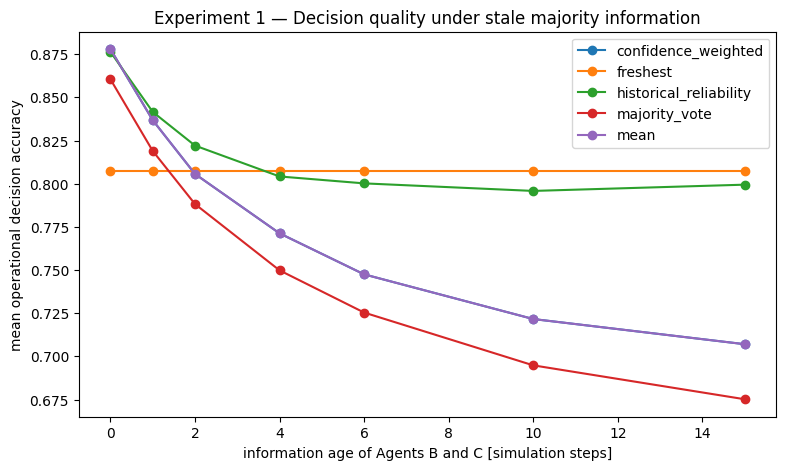

In [ ]:
plt.figure(figsize=(9, 5))
for strategy in delay_summary["strategy"].unique():
    d = delay_summary[delay_summary["strategy"] == strategy]
    plt.plot(d["delay"], d["decision_accuracy"], marker="o", label=strategy)
plt.xlabel("information age of Agents B and C [simulation steps]")
plt.ylabel("mean operational decision accuracy")
plt.title("Experiment 1 — Decision quality under stale majority information")
plt.legend()
plt.show()

### Interpretation and scope

In this model, stale observations can change the relative performance of simple fusion rules.

The experiment does not establish a general Age-of-Information law, and it does not model queueing, communication scheduling, or optimal update policies from the AoI literature.


# Experiment 2 — Correlated errors

**Label:** REPRODUCTION  
**Lineage:** distributed sensor fusion / unknown cross-correlation.

### Established result

Multiple estimates are not equivalent to multiple independent pieces of evidence when their errors share common causes.

### Reconstruction here

All sources are equally fresh and equally calibrated. We increase only the common-mode correlation parameter \(\rho\).

### Question

Does source agreement become less informative as common error dependence increases?


In [ ]:
def sweep_rho(rhos=(0.0, 0.15, 0.3, 0.5, 0.7, 0.85, 0.95), runs=30):
    rows = []
    for rho in rhos:
        for run in range(runs):
            cfg = Config(delays=(0, 0, 0), rho=rho, obs_noise=0.45, calibration_factors=(1.0, 1.0, 1.0), seed=2000 + run)
            r, _ = evaluate(cfg)
            r["rho"] = rho
            r["run"] = run
            rows.append(r)
    return pd.concat(rows, ignore_index=True)

rho_df = sweep_rho()
rho_summary = (rho_df.groupby(["rho", "strategy"], as_index=False).agg(
    decision_accuracy=("decision_accuracy", "mean"),
    mean_disagreement=("mean_disagreement", "mean"),
    false_consensus_rate=("false_consensus_rate", "mean")))
rho_summary.head(12)

,rho,strategy,decision_accuracy,mean_disagreement,false_consensus_rate
0,0.00,confidence_weighted,0.841292,0.326741,0.028833
1,0.00,freshest,0.768042,0.326741,0.028833
2,0.00,historical_reliability,0.840667,0.326741,0.028833
3,0.00,majority_vote,0.824750,0.326741,0.028833
4,0.00,mean,0.841292,0.326741,0.028833
5,0.15,confidence_weighted,0.824333,0.301240,0.042250
6,0.15,freshest,0.768708,0.301240,0.042250
7,0.15,historical_reliability,0.824792,0.301240,0.042250
8,0.15,majority_vote,0.812917,0.301240,0.042250
9,0.15,mean,0.824333,0.301240,0.042250


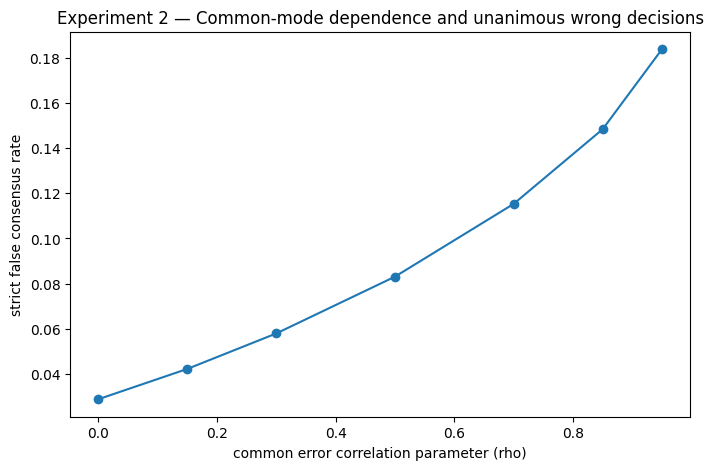

In [ ]:
majority_rho = rho_summary[rho_summary["strategy"] == "majority_vote"]
plt.figure(figsize=(8, 5))
plt.plot(majority_rho["rho"], majority_rho["false_consensus_rate"], marker="o")
plt.xlabel("common error correlation parameter (rho)")
plt.ylabel("strict false consensus rate")
plt.title("Experiment 2 — Common-mode dependence and unanimous wrong decisions")
plt.show()

### Model limitation

The error generator is a controlled statistical mechanism. Real robotic systems may share dependencies through common sensors, maps, models, communication paths, training data, or environmental disturbances. Those causal structures are not represented explicitly here.


# Experiment 3 — Confidence miscalibration

**Label:** REPRODUCTION / ADAPTATION  
**Lineage:** confidence calibration.

### Established result

Reported confidence is not automatically equivalent to empirical reliability.

### Reconstruction here

The actual sensor noise remains unchanged, but the reported uncertainty of Agents B and C is scaled by \(k\):

\[
\hat\sigma_i=k_i\sigma
\]

A small \(k\) makes the source appear more certain than it really is.

### Question

How sensitive is inverse-variance confidence weighting to overconfident stale sources?


In [ ]:
def sweep_calibration(factors=(1.5, 1.2, 1.0, 0.8, 0.6, 0.4, 0.25), runs=25):
    rows = []
    for k in factors:
        for run in range(runs):
            cfg = Config(delays=(0, 5, 5), rho=0.0, obs_noise=0.35, calibration_factors=(1.0, k, k), seed=3000 + run)
            r, _ = evaluate(cfg)
            r["stale_source_calibration_factor"] = k
            r["run"] = run
            rows.append(r)
    return pd.concat(rows, ignore_index=True)

cal_df = sweep_calibration()
cal_summary = (cal_df.groupby(["stale_source_calibration_factor", "strategy"], as_index=False).agg(
    decision_accuracy=("decision_accuracy", "mean")))
cal_summary.head(12)

,stale_source_calibration_factor,strategy,decision_accuracy
0,0.25,confidence_weighted,0.68685
1,0.25,freshest,0.80730
2,0.25,historical_reliability,0.80150
3,0.25,majority_vote,0.73455
4,0.25,mean,0.75650
5,0.40,confidence_weighted,0.69505
6,0.40,freshest,0.80730
7,0.40,historical_reliability,0.80150
8,0.40,majority_vote,0.73455
9,0.40,mean,0.75650


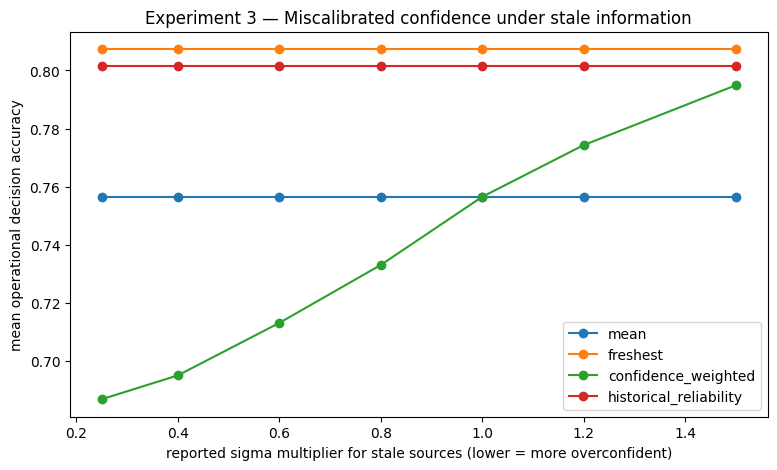

In [ ]:
plt.figure(figsize=(9, 5))
for strategy in ["mean", "freshest", "confidence_weighted", "historical_reliability"]:
    d = cal_summary[cal_summary["strategy"] == strategy].sort_values("stale_source_calibration_factor")
    plt.plot(d["stale_source_calibration_factor"], d["decision_accuracy"], marker="o", label=strategy)
plt.xlabel("reported sigma multiplier for stale sources (lower = more overconfident)")
plt.ylabel("mean operational decision accuracy")
plt.title("Experiment 3 — Miscalibrated confidence under stale information")
plt.legend()
plt.show()

# Experiment 4 — Outdated information amplified by confidence

**Label:** ADAPTATION  
**Lineage:** Mesto & Cruz, *The Consensus Paradox*.

### Literature mechanism

Mesto & Cruz study multi-teacher reinforcement learning under changing goals. Their reported result is not merely that teachers can be wrong, but that **low disagreement can coincide with severe failure when confidence-weighted aggregation amplifies outdated expertise**.

### Adaptation here

We do **not** reproduce their RL experiment.

Instead, we translate the causal structure:

- teachers → autonomous information sources,
- outdated expertise → stale local state,
- teacher confidence → reported source uncertainty,
- ensemble action → team operational decision.

### Question

Can the same qualitative failure mechanism appear in a non-RL state-sharing system?


In [ ]:
scenarios = {
    "fresh_calibrated_independent": Config(delays=(0, 0, 0), rho=0.0, calibration_factors=(1.0, 1.0, 1.0), seed=44),
    "stale_but_calibrated": Config(delays=(0, 6, 6), rho=0.0, calibration_factors=(1.0, 1.0, 1.0), seed=44),
    "stale_and_overconfident": Config(delays=(0, 6, 6), rho=0.0, calibration_factors=(1.0, 0.35, 0.35), seed=44),
}
scenario_rows = []
for scenario, cfg in scenarios.items():
    r, _ = evaluate(cfg)
    r["scenario"] = scenario
    scenario_rows.append(r)
scenario_df = pd.concat(scenario_rows, ignore_index=True)
scenario_df[["scenario", "strategy", "decision_accuracy", "rmse", "false_consensus_rate"]].sort_values(["scenario", "decision_accuracy"], ascending=[True, False])

,scenario,strategy,decision_accuracy,rmse,false_consensus_rate
0,fresh_calibrated_independent,mean,0.85875,0.202645,0.02500
2,fresh_calibrated_independent,confidence_weighted,0.85875,0.202645,0.02500
3,fresh_calibrated_independent,historical_reliability,0.85625,0.203187,0.02500
4,fresh_calibrated_independent,majority_vote,0.84875,NaN,0.02500
1,fresh_calibrated_independent,freshest,0.81125,0.345423,0.02500
11,stale_and_overconfident,freshest,0.81125,0.345423,0.06125
13,stale_and_overconfident,historical_reliability,0.79625,0.297297,0.06125
10,stale_and_overconfident,mean,0.73000,0.380895,0.06125
14,stale_and_overconfident,majority_vote,0.71375,NaN,0.06125
12,stale_and_overconfident,confidence_weighted,0.65750,0.510006,0.06125


### Interpretation

If confidence-weighted fusion deteriorates strongly in this experiment, the appropriate conclusion is limited to the simulated setting:

> *A qualitatively similar mechanism can be constructed in this simplified autonomous-team model.*

This does not establish a generalization of the Mesto–Cruz result to physical multi-robot systems.


# Experiment 5 — Combined failure surface

**Label:** SYNTHESIS  
**Lineage:** combination of AoI + calibration + unknown dependence.

This is the first section that intentionally combines mechanisms from research traditions that are often analyzed separately.

We vary:

\[
(\Delta,\rho,k)
\]

where:

- \(\Delta\): stale-source information age,
- \(\rho\): common error dependence,
- \(k\): stale-source calibration factor.

The purpose is not to find an optimum. It is to identify regions where the ranking of fusion mechanisms changes.


In [ ]:
def combined_surface(delays=(0, 3, 6, 10), rhos=(0.0, 0.4, 0.8), factors=(1.0, 0.6, 0.3), runs=10):
    rows = []
    for d in delays:
        for rho in rhos:
            for k in factors:
                for run in range(runs):
                    cfg = Config(delays=(0, d, d), rho=rho, obs_noise=0.35, calibration_factors=(1.0, k, k), seed=5000 + run)
                    r, _ = evaluate(cfg)
                    r["delay"] = d
                    r["rho"] = rho
                    r["calibration_factor"] = k
                    r["run"] = run
                    rows.append(r)
    return pd.concat(rows, ignore_index=True)

surface_df = combined_surface()
surface_summary = (surface_df.groupby(["delay", "rho", "calibration_factor", "strategy"], as_index=False).agg(
    decision_accuracy=("decision_accuracy", "mean"),
    false_consensus_rate=("false_consensus_rate", "mean")))
surface_summary.head(15)

,delay,rho,calibration_factor,strategy,decision_accuracy,false_consensus_rate
0,0,0.0,0.3,confidence_weighted,0.853250,0.0255
1,0,0.0,0.3,freshest,0.797375,0.0255
2,0,0.0,0.3,historical_reliability,0.868250,0.0255
3,0,0.0,0.3,majority_vote,0.849375,0.0255
4,0,0.0,0.3,mean,0.867375,0.0255
5,0,0.0,0.6,confidence_weighted,0.861750,0.0255
6,0,0.0,0.6,freshest,0.797375,0.0255
7,0,0.0,0.6,historical_reliability,0.868250,0.0255
8,0,0.0,0.6,majority_vote,0.849375,0.0255
9,0,0.0,0.6,mean,0.867375,0.0255


In [ ]:
best_by_condition = (surface_summary.sort_values(
    ["delay", "rho", "calibration_factor", "decision_accuracy"],
    ascending=[True, True, True, False]
).groupby(["delay", "rho", "calibration_factor"], as_index=False).first())
best_by_condition.rename(columns={"strategy": "best_strategy"}).head(20)

,delay,rho,calibration_factor,best_strategy,decision_accuracy,false_consensus_rate
0,0,0.0,0.3,historical_reliability,0.868250,0.025500
1,0,0.0,0.6,historical_reliability,0.868250,0.025500
2,0,0.0,1.0,historical_reliability,0.868250,0.025500
3,0,0.4,0.3,historical_reliability,0.836125,0.061000
4,0,0.4,0.6,historical_reliability,0.836125,0.061000
5,0,0.4,1.0,historical_reliability,0.836125,0.061000
6,0,0.8,0.3,mean,0.811750,0.115125
7,0,0.8,0.6,mean,0.811750,0.115125
8,0,0.8,1.0,confidence_weighted,0.811750,0.115125
9,3,0.0,0.3,historical_reliability,0.800875,0.054250


## 6. Synthesis — diagnosing disagreement

If different fusion strategies dominate in different regions of the \((\Delta,\rho,k)\) space, a natural question is what evidence would allow a system to infer which failure mechanism is active.

For example, the same visible disagreement pattern

\[
A \neq B=C
\]

could arise because:

1. **A is faulty**;
2. **B and C are stale**;
3. **B and C share a common-mode error**;
4. **A has detected a regime change earlier**;
5. **the environment is transitioning and no source is yet clearly authoritative**.

These situations can produce similar surface-level disagreement while requiring different coordination responses.


## 7. Research hypothesis

**HYPOTHESIS**

> **Adaptive coordination should diagnose the likely cause of disagreement before selecting a reconciliation mechanism.**

A future system could represent competing explanations as:

\[
P(H_k \mid O_{0:t}, \Delta, C, G, \mathcal{H})
\]

where \(H_k\) is a candidate cause of disagreement, \(C\) contains uncertainty or confidence information, \(G\) represents source or communication topology, and \(\mathcal{H}\) represents history.

A diagnosis could then inform responses such as:

- prioritising fresher evidence;
- discounting a suspected common-mode cluster;
- requesting another observation;
- preserving disagreement temporarily;
- switching fusion strategy;
- querying another agent;
- escalating to a human supervisor.

This hypothesis is not evaluated in the present notebook.


## 8. Conclusions and limitations

The notebook reconstructs several literature-established information failure mechanisms in one minimal autonomous-team environment and provides a reproducible comparison of simple fusion rules under changes in information age, calibration, and error dependence.

The results should be interpreted within the limits of the simulator. They do not establish consensus failure as a novel phenomenon, define `false_consensus_rate` as a general metric, represent physical robot networks, or show that confidence weighting is generally inferior.

The main research direction emerging from the synthesis is the diagnosis of disagreement causes before selecting a reconciliation mechanism.
